# Sentinel-2 Crop Health Visualizations
## Alfalfa Orchards, Central Valley, CA

Presentation-quality plots for the agentic satellite data lecture.  
Real Sentinel-2 data from Microsoft Planetary Computer for a 2 km x 2 km AOI near Madera, CA

**Sections:**
1. USDA crop classification (CDL labels + spatial map)
2. Alfalfa health reference thresholds
3. Spectral indices on real imagery (NDVI / CWSI / EVI)
4. False color composites & index overlays
5. NDVI time series
6. Baseline change detection
7. Synthetic scene reference (teaching example)

In [1]:
import os, sys, json
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib.patches as mpatches
from matplotlib.gridspec import GridSpec

# Resolve project root
_here = Path(os.getcwd())
if not (_here / 'data' / 'scenes').exists() and (_here.parent / 'data' / 'scenes').exists():
    os.chdir(_here.parent)
sys.path.insert(0, str(Path(os.getcwd())))

from agent.scene import load_scene, get_band, get_baseline_band, get_metadata
from agent.models import BoundingBox

# --- Presentation style ---
plt.rcParams.update({
    'figure.facecolor': '#0e1117',
    'axes.facecolor': '#0e1117',
    'text.color': '#fafafa',
    'axes.labelcolor': '#fafafa',
    'xtick.color': '#888888',
    'ytick.color': '#888888',
    'axes.edgecolor': '#333333',
    'figure.dpi': 120,
    'font.family': 'sans-serif',
    'font.size': 11,
    'axes.titlesize': 13,
    'axes.titleweight': 'bold',
})

ACCENT = '#00d4aa'
WARN   = '#ff6b6b'
INFO   = '#4ecdc4'
GOLD   = '#ffd93d'

print('Setup complete.')

Setup complete.


---
## 1. USDA Crop Classification Labels

Ground truth from the USDA Cropland Data Layer (CDL) via CropScape WMS.  
This shows what's actually growing in our 2 km x 2 km AOI near Madera, CA.

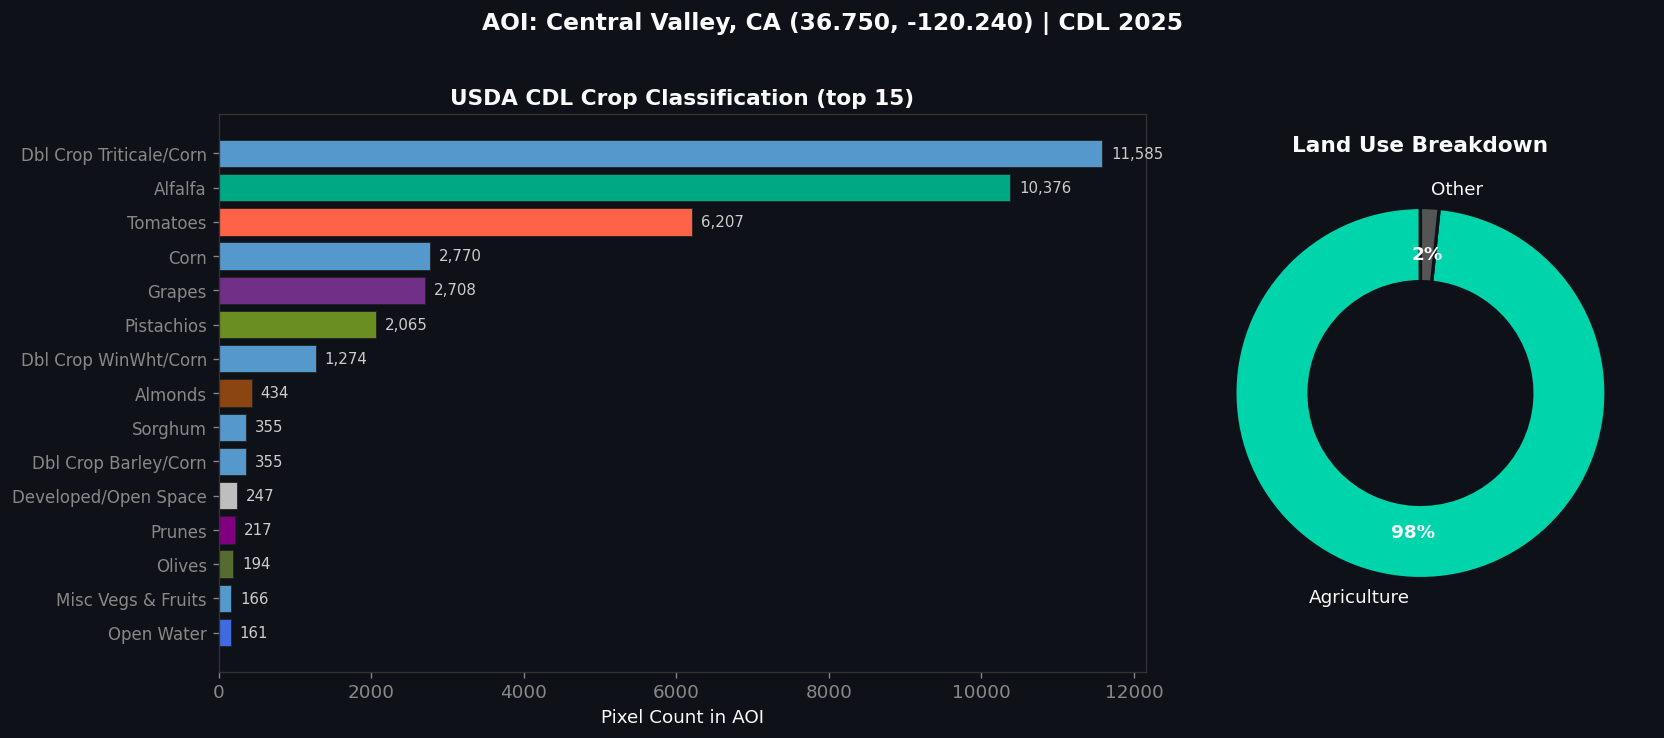

In [2]:
load_scene('central_valley')
meta = get_metadata()

gt = meta['ground_truth']
crops = gt['all_codes']
# Show top 15 crops by pixel count for readability
top_n = 15
sorted_crops = sorted(crops.items(), key=lambda x: x[1], reverse=True)[:top_n]
labels = [k for k, v in sorted_crops]
counts = [v for k, v in sorted_crops]

# Color palette for crop types
crop_colors = {
    'Almonds': '#8B4513', 'Grapes': '#722f87', 'Pistachios': '#6B8E23',
    'Citrus': '#FF8C00', 'Cherries': '#DC143C', 'Peaches': '#FFB6C1',
    'Pomegranates': '#C71585', 'Walnuts': '#A0522D', 'Prunes': '#800080',
    'Olives': '#556B2F', 'Apricots': '#FFDAB9',
    'Durum Wheat': '#DAA520', 'Winter Wheat': '#F0E68C', 'Safflower': '#FFD700',
    'Alfalfa': '#00a884', 'Tomatoes': '#FF6347', 'Onions': '#DDA0DD',
    'Garlic': '#E8E8D0', 'Broccoli': '#2E8B57',
    'Grassland/Pasture': '#90EE90', 'Fallow/Idle Cropland': '#BDB76B',
    'Developed/Open Space': '#BEBEBE', 'Developed/Low Intensity': '#A0A0A0',
    'Developed/Medium Intensity': '#808080', 'Developed/High Intensity': '#606060',
    'Barren': '#D2B48C', 'Open Water': '#4169E1',
}
colors = [crop_colors.get(l, '#5599cc') for l in labels]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6),
                                gridspec_kw={'width_ratios': [2, 1]})

# Horizontal bar chart
bars = ax1.barh(range(len(labels)), counts, color=colors, edgecolor='#222222', linewidth=0.5)
ax1.set_yticks(range(len(labels)))
ax1.set_yticklabels(labels, fontsize=10)
ax1.set_xlabel('Pixel Count in AOI', fontsize=11)
ax1.set_title(f'USDA CDL Crop Classification (top {top_n})')
ax1.invert_yaxis()
for bar, count in zip(bars, counts):
    ax1.text(bar.get_width() + max(counts)*0.01, bar.get_y() + bar.get_height()/2,
             f'{count:,}', va='center', fontsize=9, color='#cccccc')

# Donut chart — agricultural vs non-agricultural
non_ag_prefixes = ('Developed', 'Barren', 'Open Water', 'Grassland',
                   'Shrubland', 'Forest', 'Woody Wetlands', 'Herbaceous Wetlands',
                   'Perennial Ice', 'Background')
total = sum(crops.values())
non_ag_count = sum(v for k, v in crops.items()
                   if any(k.startswith(p) for p in non_ag_prefixes))
ag_count = total - non_ag_count
wedges, texts, autotexts = ax2.pie(
    [ag_count, non_ag_count],
    labels=['Agriculture', 'Other'],
    colors=[ACCENT, '#555555'],
    autopct='%1.0f%%',
    startangle=90,
    pctdistance=0.75,
    wedgeprops={'width': 0.4, 'edgecolor': '#0e1117', 'linewidth': 2},
)
for t in autotexts:
    t.set_color('#fafafa')
    t.set_fontweight('bold')
ax2.set_title('Land Use Breakdown')

fig.suptitle(f'AOI: {meta["region"]} | CDL {gt["year"]}',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('data/images/crop_classification.png', bbox_inches='tight',
            facecolor=fig.get_facecolor(), dpi=150)
plt.show()

### Crop Classification Spatial Map

The bar chart above summarizes CDL labels from a small sample at the AOI center.  
Below we fetch the full CDL raster covering our 2 km x 2 km AOI and overlay it on the satellite imagery — showing *where* each crop type is planted.

Loaded cached CDL raster: (200, 200)


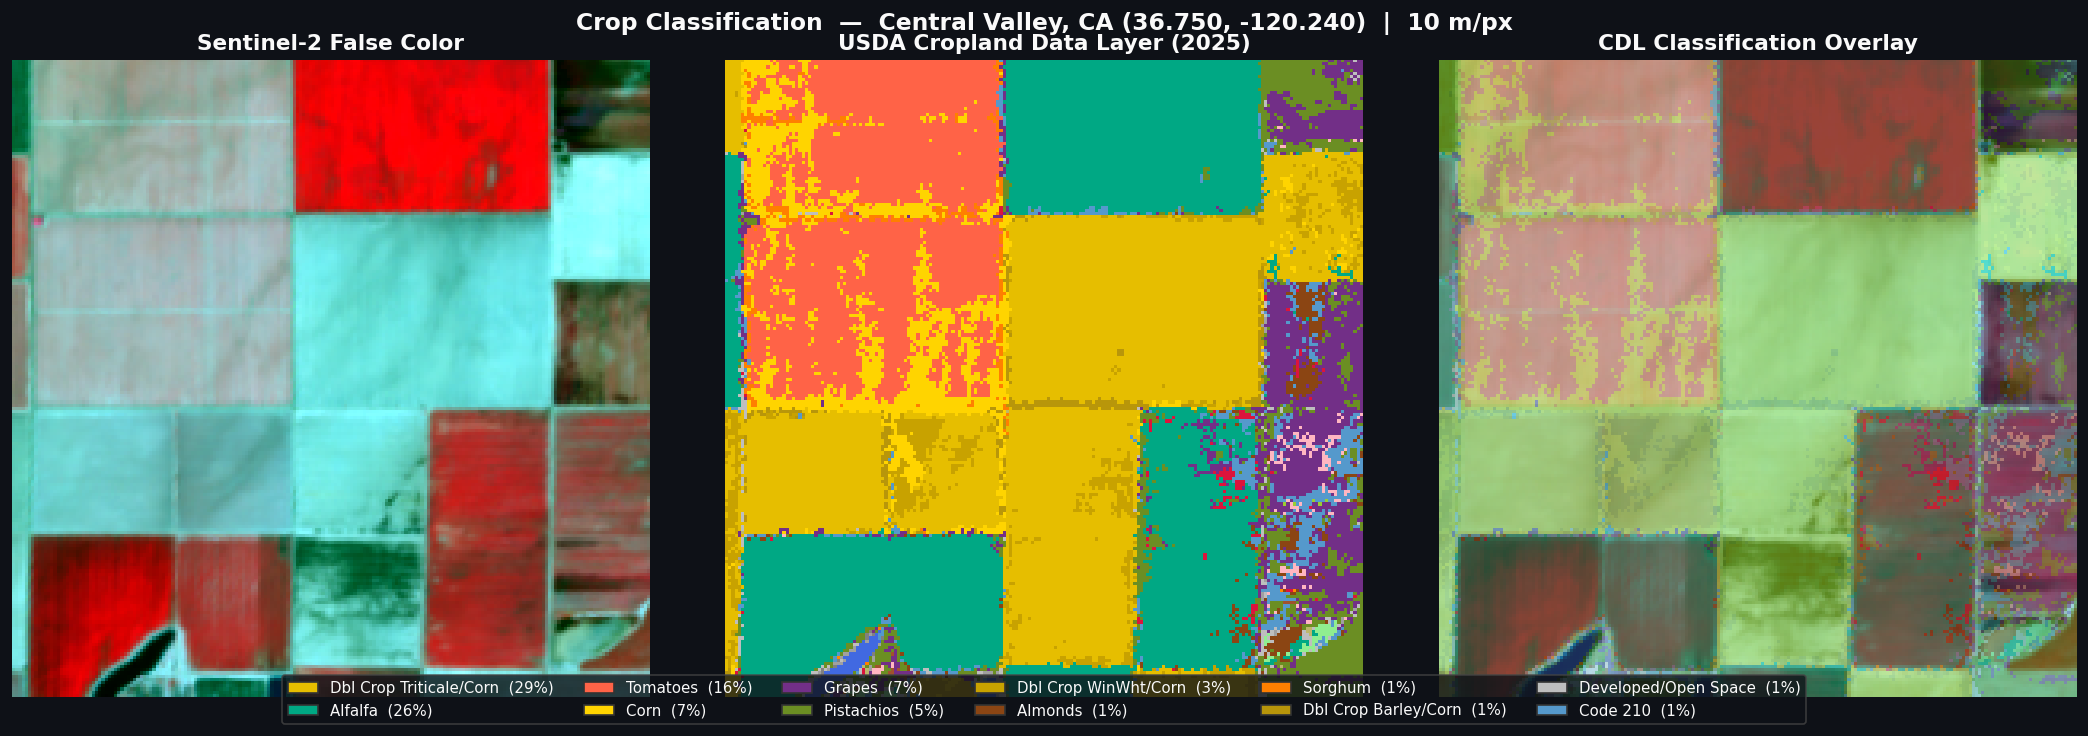


Crop breakdown (40,000 pixels, 2000m AOI):
  Dbl Crop Triticale/Corn         11,585 px  ( 29.0%)
  Alfalfa                         10,376 px  ( 25.9%)
  Tomatoes                        6,207 px  ( 15.5%)
  Corn                            2,770 px  (  6.9%)
  Grapes                          2,708 px  (  6.8%)
  Pistachios                      2,065 px  (  5.2%)
  Dbl Crop WinWht/Corn            1,274 px  (  3.2%)
  Almonds                           434 px  (  1.1%)
  Sorghum                           355 px  (  0.9%)
  Dbl Crop Barley/Corn              355 px  (  0.9%)
  Developed/Open Space              247 px  (  0.6%)
  Code 210                          217 px  (  0.5%)


In [3]:
import httpx
from io import BytesIO
import rasterio

# --- Fetch full CDL raster for AOI ---
bbox = meta['bbox_wgs84']
cdl_year = gt['year']
cdl_cache = Path(f'data/scenes/{meta["scene_id"]}_cdl_{cdl_year}.npy')

# CDL legend: code -> (name, color)  — Central Valley crops + land cover
CDL_LEGEND = {
    0: ('Background', '#000000'),
    1: ('Corn', '#FFD400'),
    4: ('Sorghum', '#FF7F00'),
    36: ('Alfalfa', '#00a884'),
    54: ('Tomatoes', '#FF6347'),
    61: ('Fallow/Idle Cropland', '#BDB76B'),
    66: ('Cherries', '#DC143C'),
    67: ('Peaches', '#FFB6C1'),
    69: ('Grapes', '#722f87'),
    72: ('Citrus', '#FF8C00'),
    75: ('Almonds', '#8B4513'),
    76: ('Walnuts', '#A0522D'),
    77: ('Pears', '#9ACD32'),
    111: ('Open Water', '#4169E1'),
    121: ('Developed/Open Space', '#BEBEBE'),
    122: ('Developed/Low Intensity', '#A0A0A0'),
    123: ('Developed/Med Intensity', '#808080'),
    124: ('Developed/High Intensity', '#606060'),
    131: ('Barren', '#D2B48C'),
    141: ('Deciduous Forest', '#228B22'),
    171: ('Grassland/Pasture', '#90EE90'),
    176: ('Grassland/Pasture', '#90EE90'),
    204: ('Pistachios', '#6B8E23'),
    225: ('Dbl Crop WinWht/Corn', '#C8A200'),
    228: ('Dbl Crop Triticale/Corn', '#E6BE00'),
    237: ('Dbl Crop Barley/Corn', '#B8960A'),
}

if cdl_cache.exists():
    cdl_arr = np.load(cdl_cache)
    print(f'Loaded cached CDL raster: {cdl_arr.shape}')
else:
    # Fetch from CropScape WMS at 200x200 to match our scene grid
    wms_bbox = f'{bbox[0]},{bbox[1]},{bbox[2]},{bbox[3]}'
    cdl_arr = None
    for try_year in [cdl_year, cdl_year - 1, cdl_year - 2]:
        layer = f'cdl_{try_year}'
        url = (
            'https://nassgeodata.gmu.edu/CropScapeService/wms_cdlall.cgi'
            f'?SERVICE=WMS&VERSION=1.1.1&REQUEST=GetMap&LAYERS={layer}'
            f'&SRS=EPSG:4326&BBOX={wms_bbox}&WIDTH=200&HEIGHT=200&FORMAT=image/tiff'
        )
        try:
            resp = httpx.get(url, timeout=30)
            if resp.status_code == 200 and 'image/tiff' in resp.headers.get('content-type', ''):
                with rasterio.open(BytesIO(resp.content)) as src:
                    cdl_arr = src.read(1)
                np.save(cdl_cache, cdl_arr)
                print(f'Fetched CDL {try_year} raster: {cdl_arr.shape}')
                break
        except Exception as e:
            print(f'CDL {try_year} fetch failed: {e}')
    if cdl_arr is None:
        print('CDL fetch failed — generating approximate map from known crop codes')
        cdl_arr = np.full((200, 200), 121, dtype=np.uint8)  # fallback

# --- Build RGB classification image ---
cdl_rgb = np.zeros((*cdl_arr.shape, 3), dtype=np.float32)
unique_codes = np.unique(cdl_arr)
found_crops = {}
for code in unique_codes:
    if code in CDL_LEGEND:
        name, hex_color = CDL_LEGEND[code]
    else:
        name, hex_color = f'Code {code}', '#5599cc'
    r, g, b = int(hex_color[1:3], 16), int(hex_color[3:5], 16), int(hex_color[5:7], 16)
    mask = cdl_arr == code
    cdl_rgb[mask] = [r/255, g/255, b/255]
    count = int(mask.sum())
    if count > 200:  # legend entries with >0.5% coverage
        found_crops[name] = (hex_color, count)

# --- False color composite for context ---
nir = get_band('B08'); red = get_band('B04'); green = get_band('B03')
def norm(b):
    lo, hi = np.percentile(b, [2, 98])
    return np.clip((b - lo) / (hi - lo + 1e-8), 0, 1)
false_color = np.stack([norm(nir), norm(red), norm(green)], axis=-1)

# --- Plot: CDL map, false color, and blended overlay ---
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

axes[0].imshow(false_color)
axes[0].set_title('Sentinel-2 False Color')
axes[0].axis('off')

axes[1].imshow(cdl_rgb)
axes[1].set_title(f'USDA Cropland Data Layer ({cdl_year})')
axes[1].axis('off')

# Blended overlay: 40% CDL + 60% false color
blended = 0.6 * false_color + 0.4 * cdl_rgb
blended = np.clip(blended, 0, 1)
axes[2].imshow(blended)
axes[2].set_title('CDL Classification Overlay')
axes[2].axis('off')

# Legend — sorted by pixel count, limited to top entries
patches = [mpatches.Patch(facecolor=c, edgecolor='#333',
                          label=f'{n}  ({ct/cdl_arr.size*100:.0f}%)')
           for n, (c, ct) in sorted(found_crops.items(), key=lambda x: -x[1][1])]
fig.legend(handles=patches, loc='lower center', ncol=min(len(patches), 6),
           fontsize=9, framealpha=0.8, edgecolor='#444',
           bbox_to_anchor=(0.5, -0.02))

fig.suptitle(f'Crop Classification  —  {meta["region"]}  |  10 m/px',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('data/images/cdl_spatial_map.png', bbox_inches='tight',
            facecolor=fig.get_facecolor(), dpi=150)
plt.show()

# Print crop breakdown
total_px = cdl_arr.size
print(f'\nCrop breakdown ({total_px:,} pixels, {meta["aoi_size_m"]}m AOI):')
for name, (_, count) in sorted(found_crops.items(), key=lambda x: -x[1][1]):
    pct = count / total_px * 100
    print(f'  {name:30s}  {count:5,d} px  ({pct:5.1f}%)')

---
## 2. Alfalfa Health Reference Card

NDVI and NDWI thresholds specific to alfalfa plantings (from UC Cooperative Extension).

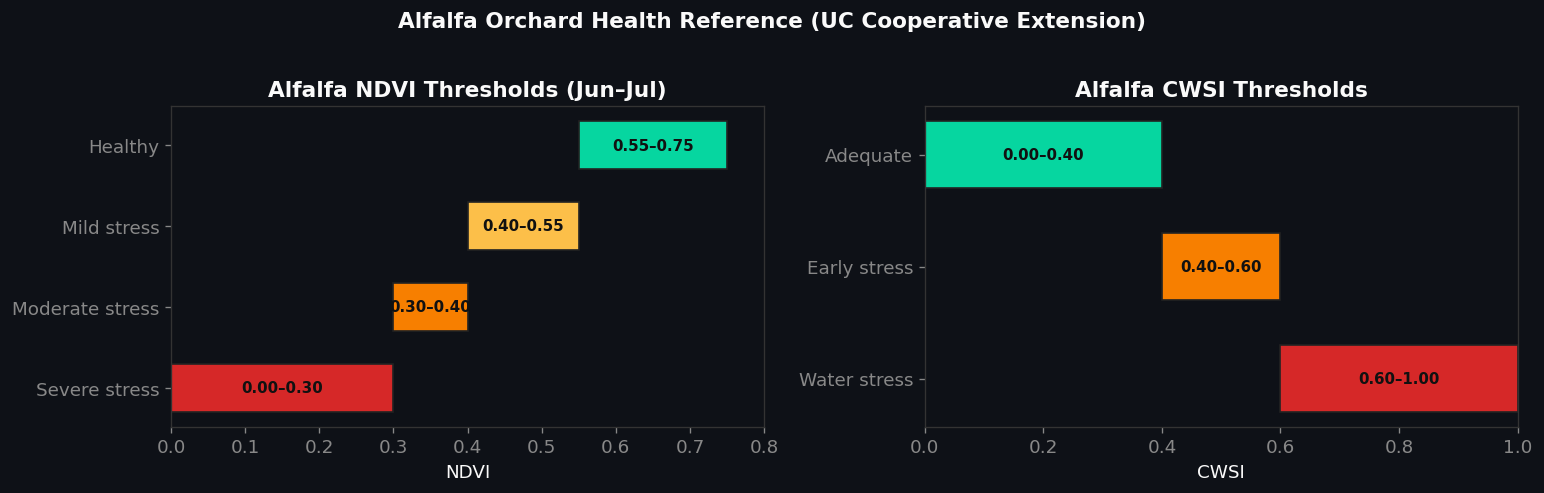

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# NDVI reference
ndvi_ranges = [
    ('Severe stress', 0.0, 0.30, '#d62828'),
    ('Moderate stress', 0.30, 0.40, '#f77f00'),
    ('Mild stress', 0.40, 0.55, '#fcbf49'),
    ('Healthy', 0.55, 0.75, '#06d6a0'),
]
for label, lo, hi, color in ndvi_ranges:
    axes[0].barh(label, hi - lo, left=lo, color=color, height=0.6,
                 edgecolor='#222222')
    axes[0].text((lo + hi) / 2, label, f'{lo:.2f}\u2013{hi:.2f}',
                 ha='center', va='center', fontsize=9, fontweight='bold',
                 color='#111111')
axes[0].set_xlabel('NDVI')
axes[0].set_title('Alfalfa NDVI Thresholds (Jun\u2013Jul)')
axes[0].set_xlim(0, 0.8)

# CWSI reference
cwsi_ranges = [
    ('Water stress', 0.6, 1.0, '#d62828'),
    ('Early stress', 0.4, 0.6, '#f77f00'),
    ('Adequate', 0.0, 0.4, '#06d6a0'),
]
for label, lo, hi, color in cwsi_ranges:
    axes[1].barh(label, hi - lo, left=lo, color=color, height=0.6,
                 edgecolor='#222222')
    axes[1].text((lo + hi) / 2, label, f'{lo:.2f}\u2013{hi:.2f}',
                 ha='center', va='center', fontsize=9, fontweight='bold',
                 color='#111111')
axes[1].set_xlabel('CWSI')
axes[1].set_title('Alfalfa CWSI Thresholds')
axes[1].set_xlim(0.0, 1.0)

fig.suptitle('Alfalfa Orchard Health Reference (UC Cooperative Extension)',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('data/images/alfalfa_reference.png', bbox_inches='tight',
            facecolor=fig.get_facecolor(), dpi=150)
plt.show()

---
## 3. Spectral Index Triptych (NDVI / CWSI / EVI)

Side-by-side spatial maps of vegetation and water stress indices computed from real Sentinel-2 bands and weather data.  
CWSI (Crop Water Stress Index) combines VPD-based atmospheric demand with NDVI as a transpiration proxy.  
Almond orchards near Madera, CA — kernel fill season (May 2025).

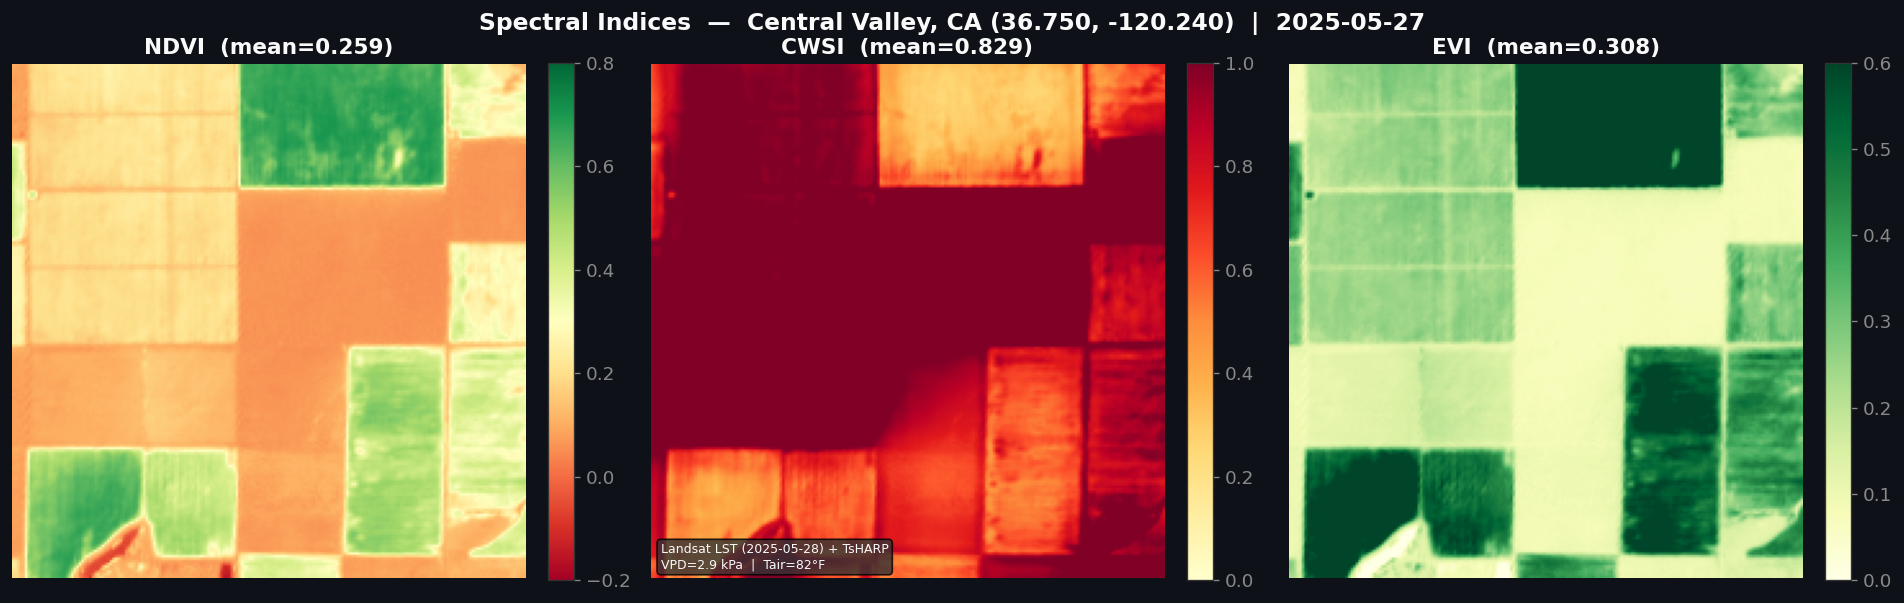

NDVI mean: 0.259  (almond healthy range: 0.55-0.75)
CWSI mean: 0.829  (0=no stress, 1=max stress; >0.5 = significant)
  Method: thermal (Landsat LST + TsHARP sharpening)
  LST range: 301.9–323.5 K
  NDVI-LST slope: -24.4 K per NDVI unit (negative = vegetation cools)
  Pixels with CWSI > 0.5: 89.1%
  Weather: VPD=2.93 kPa, Tair=82.4°F
EVI mean:  0.308


In [5]:
load_scene('central_valley')
meta = get_metadata()

nir = get_band('B08'); red = get_band('B04')
green = get_band('B03'); blue = get_band('B02')

# --- NDVI ---
ndvi = (nir - red) / (nir + red + 1e-8)

# --- CWSI (Crop Water Stress Index) from Landsat thermal ---
# Weather data from MCP weather server for scene date/location:
#   Madera, CA on 2025-05-27: air_temp=82.4°F, VPD=2.93 kPa
AIR_TEMP_F = 82.4
VPD_KPA = 2.93
TA_K = (AIR_TEMP_F - 32) * 5 / 9 + 273.15  # air temp in Kelvin

lst_raw = get_band('LST')  # Landsat surface temperature (Kelvin)

# TsHARP thermal sharpening (Agam et al. 2007):
# Downscale 100m Landsat LST to 10m using NDVI-LST relationship
from scipy.ndimage import uniform_filter
BLOCK = 10  # ~100m / 10m
ndvi_coarse = uniform_filter(ndvi, size=BLOCK, mode='nearest')
valid = ~np.isnan(lst_raw) & ~np.isnan(ndvi_coarse)
a, b = np.polyfit(ndvi_coarse[valid], lst_raw[valid], 1)
lst_sharp = a * ndvi + b + np.where(valid, lst_raw - (a * ndvi_coarse + b), 0.0)

# Empirical CWSI (Jackson et al. 1981):
# CWSI = (Tc - Tc_lower) / (Tc_upper - Tc_lower)
dt = lst_sharp - TA_K  # canopy-air temperature differential
# Non-water-stressed baseline: dT = a + b*VPD (Idso et al. 1981)
dt_lower = 1.5 - 2.0 * VPD_KPA  # well-watered almond canopy
dt_upper = 15.0  # fully stressed (no transpiration, semi-arid)
cwsi = np.clip((dt - dt_lower) / (dt_upper - dt_lower), 0, 1)

# --- EVI ---
evi = np.clip(2.5 * (nir - red) / (nir + 6*red - 7.5*blue + 1 + 1e-8), -1, 1)

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

configs = [
    ('NDVI', ndvi, 'RdYlGn', -0.2, 0.8),
    ('CWSI', cwsi, 'YlOrRd', 0.0, 1.0),
    ('EVI',  evi,  'YlGn',   0.0, 0.6),
]
for ax, (title, arr, cmap, vmin, vmax) in zip(axes, configs):
    im = ax.imshow(arr, cmap=cmap, vmin=vmin, vmax=vmax)
    cb = plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    cb.ax.tick_params(colors='#888888')
    ax.set_title(f'{title}  (mean={arr.mean():.3f})')
    ax.axis('off')

# CWSI annotation: method + weather context
landsat_info = meta.get('landsat_thermal', {})
landsat_date = landsat_info.get('date', '?')
axes[1].text(0.02, 0.02,
    f'Landsat LST ({landsat_date}) + TsHARP\nVPD={VPD_KPA:.1f} kPa  |  Tair={AIR_TEMP_F:.0f}°F',
    transform=axes[1].transAxes, fontsize=7.5, color='#fafafa',
    bbox=dict(boxstyle='round,pad=0.3', facecolor='#333333', alpha=0.8))

fig.suptitle(f'Spectral Indices  —  {meta["region"]}  |  {meta["date"]}',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('data/images/index_triptych.png', bbox_inches='tight',
            facecolor=fig.get_facecolor(), dpi=150)
plt.show()

# Interpretation
high_stress_pct = (cwsi > 0.5).mean()
print(f'NDVI mean: {ndvi.mean():.3f}  (almond healthy range: 0.55-0.75)')
print(f'CWSI mean: {cwsi.mean():.3f}  (0=no stress, 1=max stress; >0.5 = significant)')
print(f'  Method: thermal (Landsat LST + TsHARP sharpening)')
print(f'  LST range: {np.nanmin(lst_raw):.1f}–{np.nanmax(lst_raw):.1f} K')
print(f'  NDVI-LST slope: {a:.1f} K per NDVI unit (negative = vegetation cools)')
print(f'  Pixels with CWSI > 0.5: {high_stress_pct:.1%}')
print(f'  Weather: VPD={VPD_KPA:.2f} kPa, Tair={AIR_TEMP_F:.1f}°F')
print(f'EVI mean:  {evi.mean():.3f}')

---
## 4. NDVI Time Series

Tracking vegetation health over time reveals *when* stress began.  
Six Sentinel-2 passes over the AOI from April to May 2025, with almond health thresholds overlaid.

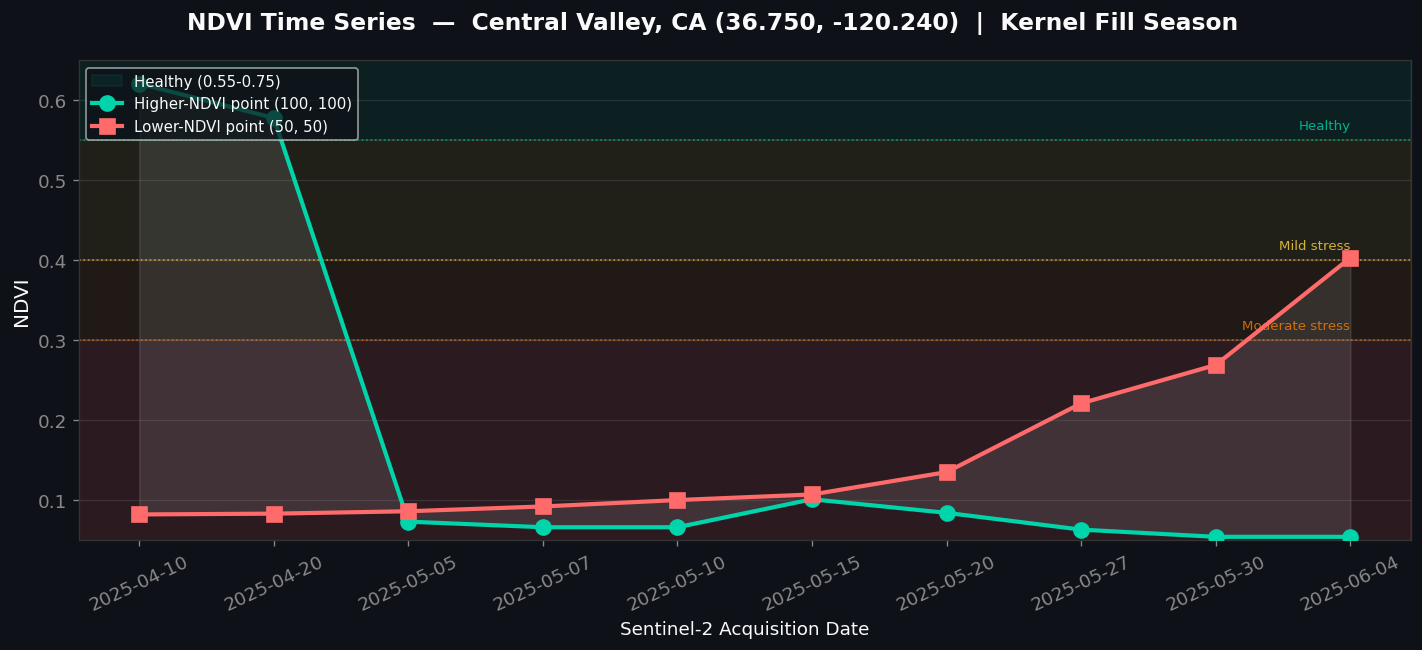

Higher point trend: -0.567 over 10 dates
Lower point trend:  +0.321 over 10 dates
Both points below almond healthy threshold (0.55) — consistent with mixed land use in AOI


In [6]:
# Central Valley time series (real Sentinel-2 data)
meta_cv = json.loads(Path('data/scenes/central_valley_metadata.json').read_text())
ts_cv = meta_cv['timeseries']
dates = ts_cv['dates']
ndvi_lo = ts_cv['stressed_point']['ndvi']
ndvi_hi = ts_cv['healthy_point']['ndvi']

fig, ax = plt.subplots(figsize=(12, 5.5))

# Almond threshold bands
ax.axhspan(0.55, 0.80, alpha=0.08, color=ACCENT, label='Healthy (0.55-0.75)')
ax.axhspan(0.40, 0.55, alpha=0.08, color=GOLD)
ax.axhspan(0.30, 0.40, alpha=0.08, color='#f77f00')
ax.axhspan(0.0,  0.30, alpha=0.12, color=WARN)

# Threshold lines
for thresh, lbl, c in [(0.55, 'Healthy', ACCENT), (0.40, 'Mild stress', GOLD),
                         (0.30, 'Moderate stress', '#f77f00')]:
    ax.axhline(thresh, color=c, linestyle=':', linewidth=1, alpha=0.6)
    ax.text(dates[-1], thresh + 0.01, lbl, fontsize=8, color=c,
            ha='right', va='bottom', alpha=0.8)

# Data
ax.plot(dates, ndvi_hi, 'o-', color=ACCENT, linewidth=2.5, markersize=9,
        label=f'Higher-NDVI point ({ts_cv["healthy_point"]["row"]}, {ts_cv["healthy_point"]["col"]})',
        zorder=5)
ax.plot(dates, ndvi_lo, 's-', color=WARN, linewidth=2.5, markersize=9,
        label=f'Lower-NDVI point ({ts_cv["stressed_point"]["row"]}, {ts_cv["stressed_point"]["col"]})',
        zorder=5)

# Fill between to show divergence
ax.fill_between(dates, ndvi_lo, ndvi_hi, alpha=0.1, color='#ffffff')

ax.set_ylabel('NDVI', fontsize=12)
ax.set_xlabel('Sentinel-2 Acquisition Date', fontsize=11)
ax.set_ylim(0.05, 0.65)
ax.legend(loc='upper left', fontsize=9, framealpha=0.7)
ax.tick_params(axis='x', rotation=25)
ax.grid(axis='y', alpha=0.15)

fig.suptitle(f'NDVI Time Series  —  {meta_cv["region"]}  |  Kernel Fill Season',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('data/images/ndvi_timeseries.png', bbox_inches='tight',
            facecolor=fig.get_facecolor(), dpi=150)
plt.show()

# Interpretation
delta_hi = ndvi_hi[-1] - ndvi_hi[0]
delta_lo = ndvi_lo[-1] - ndvi_lo[0]
print(f'Higher point trend: {delta_hi:+.3f} over {len(dates)} dates')
print(f'Lower point trend:  {delta_lo:+.3f} over {len(dates)} dates')
print(f'Both points below almond healthy threshold (0.55) — '
      f'consistent with mixed land use in AOI')

---
## 5. False Color Composites & Index Overlay

False color (NIR/Red/Green) highlights vegetation in bright red/pink tones.  
Overlaying NDVI contours connects spectral indices to the physical landscape.

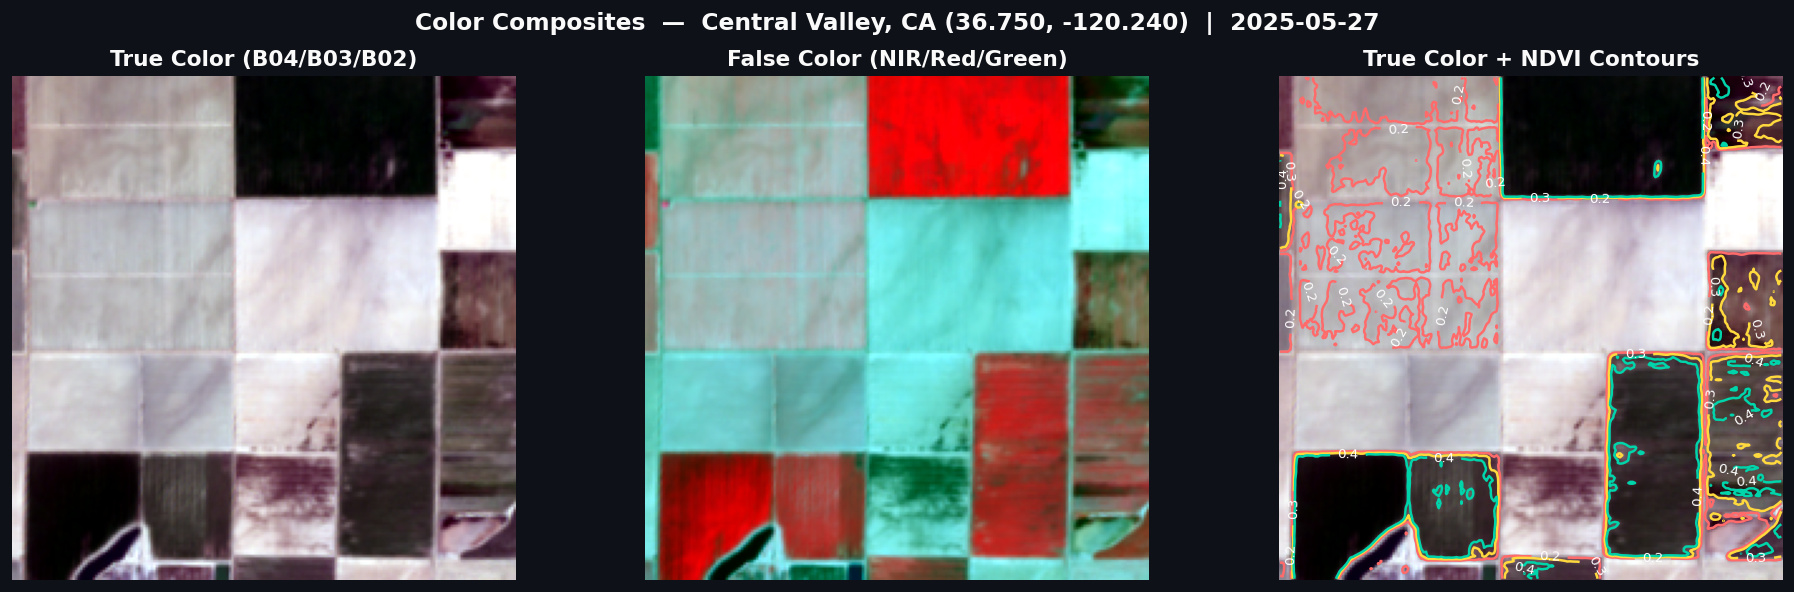

In [7]:
load_scene('central_valley')
meta = get_metadata()

nir = get_band('B08'); red = get_band('B04')
green = get_band('B03'); blue = get_band('B02')

def normalize_band(b):
    lo, hi = np.percentile(b, [2, 98])
    return np.clip((b - lo) / (hi - lo + 1e-8), 0, 1)

# True color (R=B04, G=B03, B=B02)
true_color = np.stack([normalize_band(red),
                        normalize_band(green),
                        normalize_band(blue)], axis=-1)

# False color (R=NIR, G=Red, B=Green)
false_color = np.stack([normalize_band(nir),
                         normalize_band(red),
                         normalize_band(green)], axis=-1)

ndvi = (nir - red) / (nir + red + 1e-8)

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

axes[0].imshow(true_color)
axes[0].set_title('True Color (B04/B03/B02)')
axes[0].axis('off')

axes[1].imshow(false_color)
axes[1].set_title('False Color (NIR/Red/Green)')
axes[1].axis('off')

# True color with NDVI contours overlaid
axes[2].imshow(true_color)
cs = axes[2].contour(ndvi, levels=[0.2, 0.3, 0.4],
                      colors=[WARN, GOLD, ACCENT], linewidths=1.5)
axes[2].clabel(cs, fmt='%.1f', fontsize=8, colors='white')
axes[2].set_title('True Color + NDVI Contours')
axes[2].axis('off')

fig.suptitle(f'Color Composites  —  {meta["region"]}  |  {meta["date"]}',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('data/images/color_composites.png', bbox_inches='tight',
            facecolor=fig.get_facecolor(), dpi=150)
plt.show()

---
## 6. Baseline Change Detection

Comparing the current scene against the baseline on Sentinel-2 data.  
Short temporal baselines detect rapid-onset stress like irrigation failures or heat events.

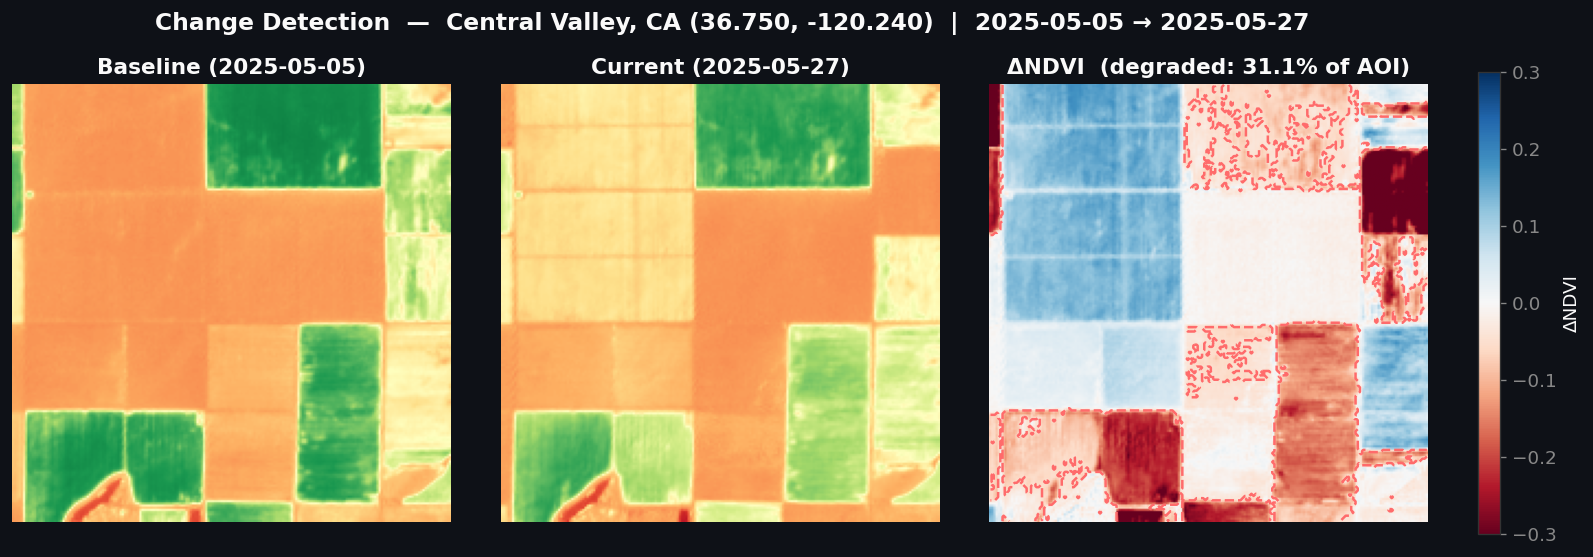

Mean ΔNDVI: -0.015
Pixels with >0.05 degradation: 31.1%
Pixels with >0.05 improvement: 29.6%


In [8]:
load_scene('central_valley')
meta = get_metadata()

nir_c = get_band('B08'); red_c = get_band('B04')
ndvi_current = (nir_c - red_c) / (nir_c + red_c + 1e-8)

region = BoundingBox(0, 200, 0, 200)
nir_b = get_baseline_band('B08', region); red_b = get_baseline_band('B04', region)
ndvi_baseline = (nir_b - red_b) / (nir_b + red_b + 1e-8)

diff = ndvi_current - ndvi_baseline
degraded_mask = diff < -0.05  # tighter threshold for short baseline

fig = plt.figure(figsize=(16, 5))
gs = GridSpec(1, 4, width_ratios=[1, 1, 1, 0.05], wspace=0.15)

ax0 = fig.add_subplot(gs[0])
im0 = ax0.imshow(ndvi_baseline, cmap='RdYlGn', vmin=-0.2, vmax=0.8)
ax0.set_title(f'Baseline ({meta["baseline_date"]})')
ax0.axis('off')

ax1 = fig.add_subplot(gs[1])
im1 = ax1.imshow(ndvi_current, cmap='RdYlGn', vmin=-0.2, vmax=0.8)
ax1.set_title(f'Current ({meta["date"]})')
ax1.axis('off')

ax2 = fig.add_subplot(gs[2])
im2 = ax2.imshow(diff, cmap='RdBu', vmin=-0.3, vmax=0.3)
ax2.contour(degraded_mask.astype(float), levels=[0.5],
            colors=[WARN], linewidths=1.5, linestyles='--')
ax2.set_title(f'\u0394NDVI  (degraded: {degraded_mask.mean():.1%} of AOI)')
ax2.axis('off')

cax = fig.add_subplot(gs[3])
plt.colorbar(im2, cax=cax, label='\u0394NDVI')
cax.yaxis.label.set_color('#fafafa')
cax.tick_params(colors='#888888')

fig.suptitle(f'Change Detection  —  {meta["region"]}  |  '
             f'{meta["baseline_date"]} \u2192 {meta["date"]}',
             fontsize=14, fontweight='bold')
plt.savefig('data/images/baseline_change.png', bbox_inches='tight',
            facecolor=fig.get_facecolor(), dpi=150)
plt.show()

print(f'Mean \u0394NDVI: {diff.mean():+.3f}')
print(f'Pixels with >0.05 degradation: {degraded_mask.mean():.1%}')
print(f'Pixels with >0.05 improvement: {(diff > 0.05).mean():.1%}')

---
## 7. Synthetic Scene Reference

Scene A is a synthetic dataset with a deliberate NW-quadrant water stress anomaly.  
This clean signal is useful for demonstrating how the agent's tools work before moving to real data.

In [ ]:
load_scene('scene_a')
meta = get_metadata()

nir = get_band('B08'); red = get_band('B04')
ndvi = (nir - red) / (nir + red + 1e-8)

fig = plt.figure(figsize=(16, 10))
gs = GridSpec(2, 3, hspace=0.3, wspace=0.3)

# --- (0,0) NDVI spatial map with anomaly grid ---
ax_map = fig.add_subplot(gs[0, 0:2])
im = ax_map.imshow(ndvi, cmap='RdYlGn', vmin=-0.2, vmax=1.0)
# 4x4 grid overlay
for i in range(1, 4):
    ax_map.axhline(i * 50, color='#ffffff', alpha=0.3, linewidth=0.5)
    ax_map.axvline(i * 50, color='#ffffff', alpha=0.3, linewidth=0.5)
# Flag anomalous cells (NW quadrant in scene A)
for gi in range(2):
    for gj in range(2):
        cell = ndvi[gi*50:(gi+1)*50, gj*50:(gj+1)*50]
        if (cell < 0.3).mean() > 0.3:
            rect = plt.Rectangle((gj*50, gi*50), 50, 50, linewidth=2,
                                  edgecolor=WARN, facecolor=WARN, alpha=0.15)
            ax_map.add_patch(rect)
plt.colorbar(im, ax=ax_map, fraction=0.046)
ax_map.set_title('NDVI Map + Anomaly Grid (4x4)')
ax_map.axis('off')

# --- (0,2) NDVI histogram ---
ax_hist = fig.add_subplot(gs[0, 2])
ax_hist.hist(ndvi.flatten(), bins=60, color=ACCENT, alpha=0.8, edgecolor='none')
ax_hist.axvline(0.3, color=WARN, linestyle='--', linewidth=2, label='Stress threshold')
ax_hist.axvline(ndvi.mean(), color=GOLD, linestyle='-', linewidth=2, label=f'Mean={ndvi.mean():.3f}')
ax_hist.set_xlabel('NDVI')
ax_hist.set_ylabel('Pixel Count')
ax_hist.set_title('NDVI Distribution')
ax_hist.legend(fontsize=9, framealpha=0.7)

# --- (1,0:2) Time series ---
ax_ts = fig.add_subplot(gs[1, 0:2])
ts = meta['timeseries']
dates = ts['dates']
ax_ts.plot(dates, ts['healthy_point']['ndvi'], 'o-', color=ACCENT,
           linewidth=2.5, markersize=8, label='Healthy (150, 150)')
ax_ts.plot(dates, ts['stressed_point']['ndvi'], 's-', color=WARN,
           linewidth=2.5, markersize=8, label='Stressed (50, 50)')
ax_ts.axhspan(0, 0.30, alpha=0.12, color=WARN)
ax_ts.set_ylabel('NDVI')
ax_ts.set_ylim(0, 0.9)
ax_ts.set_title('Temporal Trend')
ax_ts.legend(fontsize=9)
ax_ts.tick_params(axis='x', rotation=30)
ax_ts.grid(axis='y', alpha=0.2)

# --- (1,2) Summary stats ---
ax_info = fig.add_subplot(gs[1, 2])
ax_info.axis('off')
stats = [
    ('Scene', meta['scene_id']),
    ('Date', meta['date']),
    ('Mean NDVI', f'{ndvi.mean():.3f}'),
    ('Stressed px', f'{(ndvi < 0.3).mean():.1%}'),
    ('NW quad mean', f'{ndvi[:100,:100].mean():.3f}'),
    ('SE quad mean', f'{ndvi[100:,100:].mean():.3f}'),
    ('Baseline', meta.get('baseline_date', 'N/A')),
    ('Trend', 'Declining (NW)'),
]
for i, (k, v) in enumerate(stats):
    y = 0.92 - i * 0.11
    ax_info.text(0.05, y, k, fontsize=11, fontweight='bold',
                transform=ax_info.transAxes, color='#aaaaaa')
    ax_info.text(0.55, y, str(v), fontsize=11,
                transform=ax_info.transAxes, color='#fafafa')

fig.suptitle('Crop Health Diagnostic Dashboard  \u2014  Scene A',
             fontsize=16, fontweight='bold', y=0.98)
plt.savefig('data/images/diagnostic_dashboard.png', bbox_inches='tight',
            facecolor=fig.get_facecolor(), dpi=150)
plt.show()